Name: Dev Patel 

Course: DS4400 Data Mining and Machine Learning 1

Prof: Silvio Amir

University: Northeastern University

Problem 2: Random Forest Ensemble

1. Train Random Forest with T in {10, 50, 100, 500}. Report accuracy, F1, AUC on train and test.
2. Compare with Decision Tree metrics from Problem 1.
3. Compute and plot variable importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
# Load SPAMBASE dataset
col_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total',
    'spam'
]

df = pd.read_csv('spambase.data', header=None, names=col_names)
X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (3450, 57), X_test: (1151, 57)


### Part 1: Random Forest with Varying Number of Trees

In [3]:
# Train Random Forest with different numbers of trees
n_trees_list = [10, 50, 100, 500]
rf_results = []

for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    y_train_proba = rf.predict_proba(X_train)[:, 1]
    y_test_proba = rf.predict_proba(X_test)[:, 1]
    
    rf_results.append({
        'T': n_trees,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Train AUC': roc_auc_score(y_train, y_train_proba),
        'Test AUC': roc_auc_score(y_test, y_test_proba),
    })

rf_df = pd.DataFrame(rf_results)
print("Random Forest Results:")
print(rf_df.to_string(index=False))

Random Forest Results:
  T  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC
 10        0.995652       0.946134  0.994380 0.932900   0.999888  0.981758
 50        0.999420       0.958297  0.999253 0.948164   0.999998  0.988413
100        0.999420       0.958297  0.999253 0.948164   0.999998  0.987917
500        0.999420       0.957428  0.999253 0.947141   0.999999  0.987630


**Observations on Random Forest with varying T:**

- Training accuracy remains very high (near perfect) for all values of T, since each individual tree in the forest can still overfit.
- Test accuracy, F1, and AUC generally improve as T increases, especially from T=10 to T=50/100. The improvement diminishes beyond T=100, showing diminishing returns.
- Increasing T reduces variance by averaging more trees, which improves generalization. However, after a certain point (around T=100-500), adding more trees provides marginal benefit.

### Part 2: Comparison with Decision Tree

In [4]:
# Train single decision tree (entropy, no pruning) for comparison
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)
y_train_proba_dt = dt.predict_proba(X_train)[:, 1]
y_test_proba_dt = dt.predict_proba(X_test)[:, 1]

print("=== Comparison: Single Decision Tree vs Random Forest ===\n")
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Train F1':>10} {'Test F1':>10} {'Train AUC':>10} {'Test AUC':>10}")
print("-" * 82)
print(f"{'Decision Tree':<20} {accuracy_score(y_train, y_train_pred_dt):>10.4f} {accuracy_score(y_test, y_test_pred_dt):>10.4f} "
      f"{f1_score(y_train, y_train_pred_dt):>10.4f} {f1_score(y_test, y_test_pred_dt):>10.4f} "
      f"{roc_auc_score(y_train, y_train_proba_dt):>10.4f} {roc_auc_score(y_test, y_test_proba_dt):>10.4f}")

for _, row in rf_df.iterrows():
    print(f"{'RF (T=' + str(int(row['T'])) + ')':<20} {row['Train Accuracy']:>10.4f} {row['Test Accuracy']:>10.4f} "
          f"{row['Train F1']:>10.4f} {row['Test F1']:>10.4f} "
          f"{row['Train AUC']:>10.4f} {row['Test AUC']:>10.4f}")

=== Comparison: Single Decision Tree vs Random Forest ===

Model                 Train Acc   Test Acc   Train F1    Test F1  Train AUC   Test AUC
----------------------------------------------------------------------------------
Decision Tree            0.9994     0.9235     0.9993     0.9060     1.0000     0.9189
RF (T=10)                0.9957     0.9461     0.9944     0.9329     0.9999     0.9818
RF (T=50)                0.9994     0.9583     0.9993     0.9482     1.0000     0.9884
RF (T=100)               0.9994     0.9583     0.9993     0.9482     1.0000     0.9879
RF (T=500)               0.9994     0.9574     0.9993     0.9471     1.0000     0.9876


**Observations - Random Forest vs Decision Tree:**

- Both models achieve near-perfect training metrics, but Random Forest significantly outperforms the single decision tree on the test set.
- The gap between training and testing performance is much smaller for Random Forest, indicating less overfitting. This is because the ensemble averages out the variance of individual trees.
- Random Forest benefits from bagging (bootstrap aggregating) and random feature selection at each split, which decorrelates the individual trees and reduces overall variance.
- Even with just T=10 trees, the Random Forest already shows improved test performance over a single tree.

### Part 3: Variable Importance

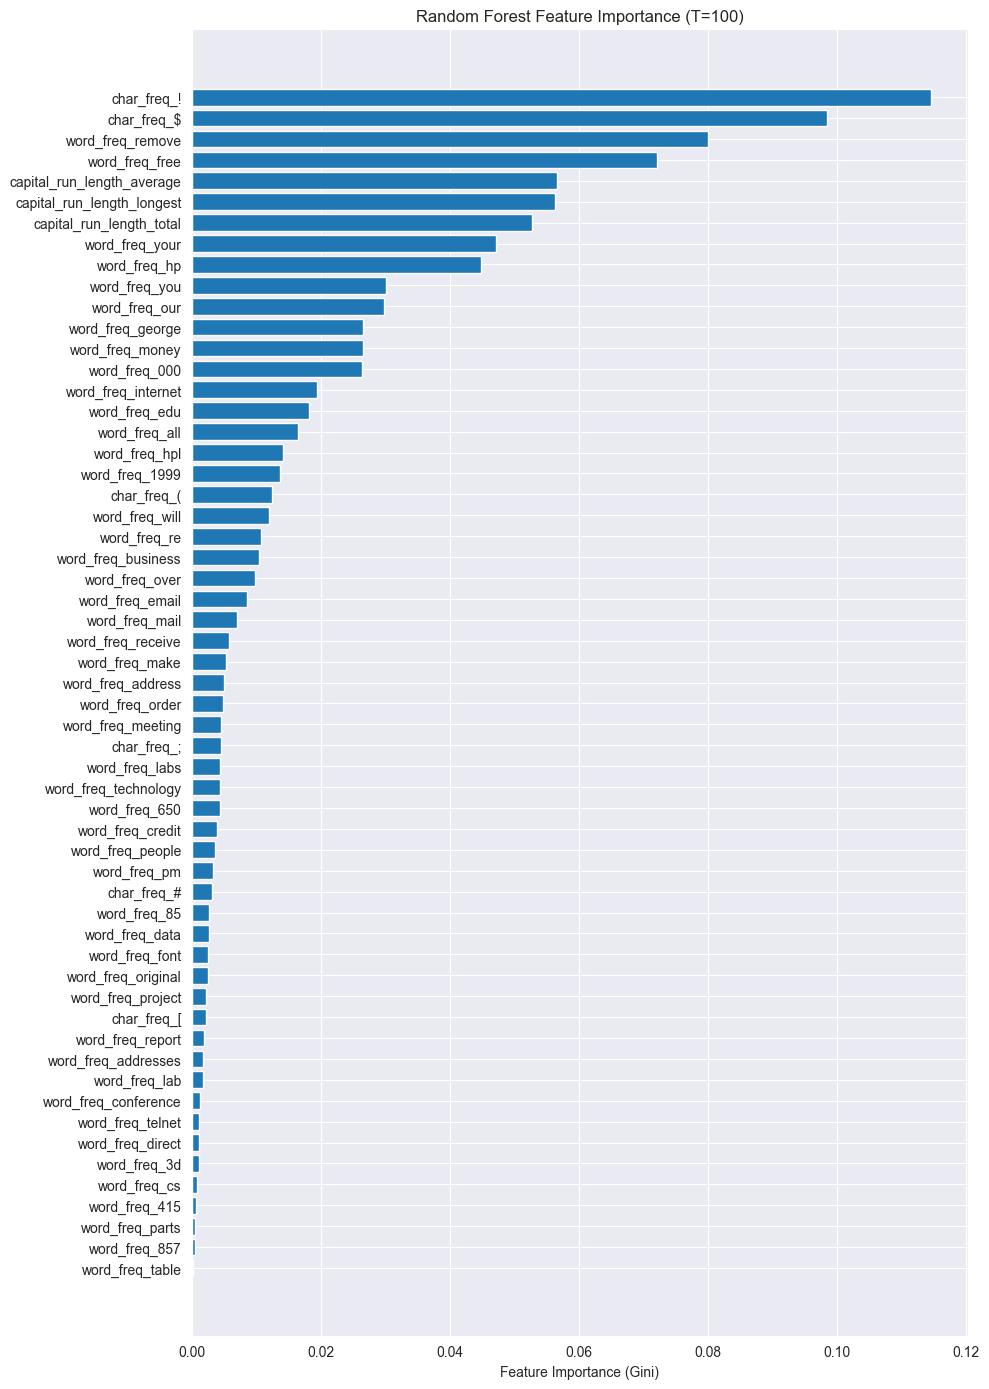


Top 10 Most Important Features:
  char_freq_!                         0.1145
  char_freq_$                         0.0984
  word_freq_remove                    0.0800
  word_freq_free                      0.0721
  capital_run_length_average          0.0566
  capital_run_length_longest          0.0564
  capital_run_length_total            0.0527
  word_freq_your                      0.0471
  word_freq_hp                        0.0449
  word_freq_you                       0.0301


In [5]:
# Use RF with 100 trees for feature importance
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)

importances = rf_100.feature_importances_
feature_names = X.columns

# Sort by importance
sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 14))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest Feature Importance (T=100)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 features
print("\nTop 10 Most Important Features:")
top_idx = sorted_idx[-10:][::-1]
for i in top_idx:
    print(f"  {feature_names[i]:<35} {importances[i]:.4f}")